In [3]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 07:03:03--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 07:03:03--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.1MB/s    in 5.0s    

2026-04-20 07:03:09 (12.2 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



# 얼굴을 점으로 표현 

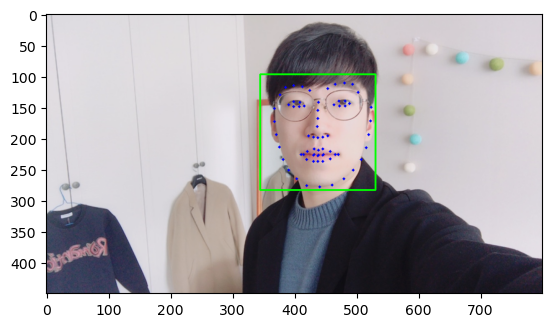

In [19]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

detector_hog = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png')
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy()

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2)

    shape = predictor(img_rgb, dlib_rect)

    for i in range(68):
        x = shape.part(i).x
        y = shape.part(i).y
        cv2.circle(img_show, (x, y), 2, (255,0,0), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

# 코 적용 위치 확인 

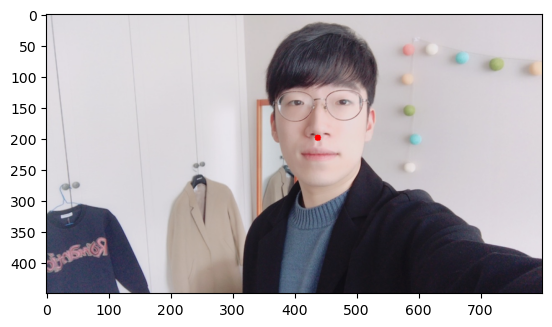

In [20]:
img_show2 = img_bgr.copy()
for dlib_rect in dlib_rects:
    shape = predictor(img_rgb, dlib_rect)

    nx = shape.part(33).x
    ny = shape.part(33).y
    cv2.circle(img_show2, (nx, ny), 5, (0,0,255), -1)

img_show2_rgb = cv2.cvtColor(img_show2, cv2.COLOR_BGR2RGB)
plt.imshow(img_show2_rgb)
plt.show()

# 고양이 수염 적용

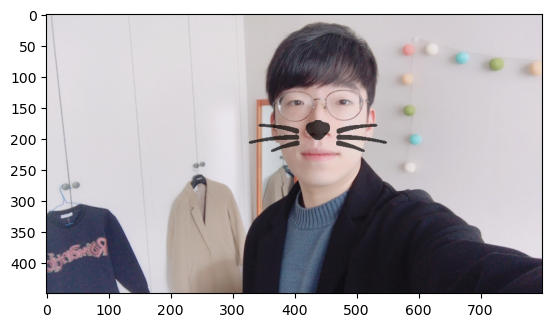

In [22]:
whisker = cv2.imread("cat-whiskers.png", cv2.IMREAD_UNCHANGED)
img_result = img_bgr.copy()

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    r = dlib_rect.right()
    shape = predictor(img_rgb, dlib_rect)

    left_x  = shape.part(31).x
    left_y  = shape.part(31).y
    right_x = shape.part(35).x
    right_y = shape.part(35).y

    nx = (left_x + right_x) // 2
    ny = (left_y + right_y) // 2

    face_width = r - l
    whisker_w = int(face_width * 1.2)
    whisker_h = int(whisker_w * whisker.shape[0] / whisker.shape[1])
    whisker_resized = cv2.resize(whisker, (whisker_w, whisker_h))

    x = nx - whisker_w // 2
    y = ny - whisker_h // 2

    if y < 0 or x < 0:
        continue
    if y + whisker_h > img_result.shape[0]:
        continue
    if x + whisker_w > img_result.shape[1]:
        continue

    alpha = whisker_resized[:, :, 3]
    sticker_bgr = whisker_resized[:, :, :3]

    roi = img_result[y:y+whisker_h, x:x+whisker_w].copy()

    blended = cv2.addWeighted(sticker_bgr, 0.7, roi, 0.3, 0)

    img_result[y:y+whisker_h, x:x+whisker_w] = np.where(
        alpha[:, :, np.newaxis] > 0,
        blended,
        roi
    )

img_result_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
plt.imshow(img_result_rgb)
plt.show()